# Filter out tracks based on criteria

In [3]:
import pandas as pd 
import numpy as np 
import sys
import napari
import zarr
import dask.array as da
import os
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.notebook import tqdm
pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)

from filters import Track, create_tracks_from_dataframe, drop_short_tracks
from filters import drop_early_peak_tracks, drop_last_frame_peak_tracks, drop_tracks_below_intensity
from filters import plot_z_sum, allocate_membrane_regions, plot_z_sum_bd
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

ModuleNotFoundError: No module named 'napari'

Do not change the code in the cell below 

In [65]:
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20250917_MALum/Optimization/20250917_MA3Sl1Ch2_FirstTimepoint-01_AcquisitionBlock13_ReConvolved_analysis/'

# # If a folder named 'datasets' doesn't exist in base_dir + input_file_directory, it will be created
# if not os.path.exists(os.path.join(base_dir, input_file_directory, 'datasets')):
#     os.makedirs(os.path.join(base_dir, input_file_directory, 'datasets'))

zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

input_directory = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'

# List which channel was used for detection and tracking
channel_detected = 3

output_directory = 'datasets'
output_file_name = 'filtered_tracks_final.pkl'
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)

In [4]:
# # This assumes that your notebook is inside 'Jupyter Notebooks', which is at the same level as 'test_data'
# base_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'movie_data')

# zarr_directory = 'zarr_file/all_channels_data'
# zarr_full_path = os.path.join(base_dir, zarr_directory)

# input_directory = 'datasets'
# input_file_name = 'track_df_cleaned_final_full.pkl'
# input_directory_full = os.path.join(base_dir,input_directory, input_file_name)

# output_directory = 'datasets'
# output_file_name = 'filtered_tracks_final.pkl'
# output_directory_full = os.path.join(base_dir,output_directory, output_file_name)

In [66]:
# open tracks and movie
track_df = pd.read_pickle(input_directory)

z2 = zarr.open(zarr_full_path, mode='r')


## Set filtering parameters below

In [107]:
# Change framerate to match the current dataset
framerate_msec = 1550

#Calculate the number of frames to drop; considering ~8 seconds
drop_frames = round(8/(framerate_msec/1000))

# Drop tracks shorter than this length (in frames) -- fixing this to be as close to ~8 seconds across all datasets
threshold_length = drop_frames

# Drop tracks in which the peak intensity happens at or before this frame
peak_cutoff = drop_frames

# set this to false if you don't want to classify by apical, lateral, basal
membrane_regions_exist = False

# set default channel names (optionally adjust)

channel1_name = 'channel 1'
channel2_name = 'channel 2'
channel3_name = 'channel 3'


In [108]:
# This is the minimum intensity value that a specific channel within a track must achieve to be considered positive for that channel.
threshold_intensity_channel_1 = 1000
threshold_intensity_channel_2 = 1000

In [109]:
tracks = create_tracks_from_dataframe(df = track_df, intensities_col_name = ['c3_peak_mean', 'c2_peak_mean', 'c1_peak_mean'], 
track_id_col_name = 'track_id', frame_col_name = 'frame', coords = ['mu_x', 'mu_y', 'mu_z'])

In [110]:
# Create DataFrame from Track instances
tracks_data = {
    'mu_x': [track.x for track in tracks],
    'mu_y': [track.y for track in tracks],
    'mu_z': [track.z for track in tracks],
    'track_id': [track.track_id.values[0] for track in tracks],
    'track_length': [track.track_length for track in tracks],
    'track_start': [track.track_start for track in tracks],
    'track_end': [track.track_end for track in tracks],
    'c3_peak': [track.peak_intensities[0] for track in tracks],
    'c2_peak': [track.peak_intensities[1] for track in tracks],
    'c1_peak': [track.peak_intensities[2] for track in tracks],
    'c3_peak_frame': [track.peak_intensity_frames[0] for track in tracks],
    'c2_peak_frame': [track.peak_intensity_frames[1] for track in tracks],
    'c1_peak_frame': [track.peak_intensity_frames[2] for track in tracks],
    'mean_displacement': [track.mean_displacement_track for track in tracks],
    'mean_z': [track.mean_z_value for track in tracks],
    'mean_z_displacement': [track.mean_z_displacement for track in tracks], 
    'max_radius_from_origin': [track.max_radius_from_origin for track in tracks], 
    'max_distance_between_two_points': [track.max_distance_between_two_points for track in tracks], 
    'c3_voxel_sum_adjusted': [track.adjusted_voxel_sum_c3 for track in tracks],
    'c2_voxel_sum_adjusted': [track.adjusted_voxel_sum_c2 for track in tracks],
    'c1_voxel_sum_adjusted': [track.adjusted_voxel_sum_c1 for track in tracks],
    'c3_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[2] for track in tracks],
    'c3_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[2] for track in tracks],
    'max_z_movement': [track.max_z_movement for track in tracks],
    'max_y_movement': [track.max_y_movement for track in tracks],
    'max_x_movement': [track.max_x_movement for track in tracks],
}

tracks_df = pd.DataFrame(tracks_data)

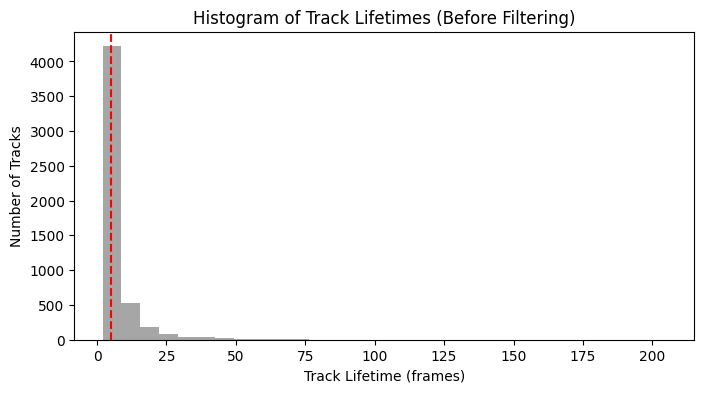

Percentage of tracks under 5 frames: 63.94%


In [73]:
#show histogram of lifetimes before filtering

plt.figure(figsize=(8, 4))
plt.hist(tracks_df['track_length'], bins=30, color='gray', alpha=0.7)
plt.axvline(x=threshold_length, color='red', linestyle='--')
plt.title('Histogram of Track Lifetimes (Before Filtering)')
plt.xlabel('Track Lifetime (frames)')
plt.ylabel('Number of Tracks')
plt.show()

#print percentage of tracks under the cutoff
percentage_under_cutoff = (tracks_df[tracks_df['track_length'] < threshold_length].shape[0] / tracks_df.shape[0]) * 100
print(f"Percentage of tracks under {threshold_length} frames: {percentage_under_cutoff:.2f}%")

### Filtering Functions

In [11]:
def filter_pixel_spots(tracks, pixel_edge, x_max, y_max, z_max):
    '''
    Filters outs that are close to the pixel edges in any dimension at any point in the track.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    pixel_edge (int): Number of pixels from the edge to consider as "close"
    x_max (int): Maximum x dimension of the image
    y_max (int): Maximum y dimension of the image
    z_max (int): Maximum z dimension of the image

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that are not close to the edges
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in range(len(tracks)):
        test = any(np.array(tracks_df["mu_x"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_y"][i].tolist()) > pixel_edge) \
                & any(np.array(tracks_df["mu_z"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_x"][i].tolist()) < x_max - pixel_edge) \
                & any(np.array(tracks_df["mu_y"][i].tolist()) < y_max - pixel_edge) & any(np.array(tracks_df["mu_z"][i].tolist()) < z_max - pixel_edge)
        mask[i] = test
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

def filter_track_frames(tracks, filter_start = 0, filter_end = z2.shape[0]):
    '''
    Filters out tracks that start before filter_start or end after filter_end.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    filter_start (int): Frame number before which tracks will be filtered out
    filter_end (int): Frame number after which tracks will be filtered out
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that start after filter_start and end before
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''

    mask = pd.Series(True, index=tracks.index)
    if filter_start is not None:
        mask &= tracks["track_start"] > filter_start
    if filter_end is not None:
        mask &= tracks["track_end"] < filter_end
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [12]:
def measure_rolling_linearity(track_df, track_id, channel='c3_voxel_sum_adjusted', window_size=4):
    """
    Measure the linearity across rolling windows of n datapoints for a track.
    
    Parameters:
    track_df (DataFrame): Full track dataframe
    track_id (int): Track ID to analyze
    channel (str): Channel column to analyze
    window_size (int): Size of rolling window (default: 4)
    
    Returns:
    dict: Contains arrays of slopes, r_squared values, and window info
    """
    mask = pd.Series(True, index=tracks_df.index)
    # Get track data
    track_data = track_df[track_df['track_id'] == track_id].copy()
    
    if len(track_data) < window_size:
        return {
            'slopes': [],
            'r_squared_values': [],
            'window_starts': [],
            'window_ends': [],
            'error': f'Track has only {len(track_data)} points, need at least {window_size}'
        }
    
    # Sort by frame to ensure correct order
    track_data = track_data.sort_values('frame')
    
    # Initialize lists to store results
    slopes = []
    r_squared_values = []
    window_starts = []
    window_ends = []
    
    # Calculate number of possible windows
    num_windows = len(track_data) - window_size + 1
    
    # Iterate through all possible windows
    for i in range(num_windows):
        # Get window data
        window_data = track_data.iloc[i:i+window_size]
        
        # Extract x (frame) and y (intensity) values
        x = window_data['frame'].values
        y = window_data[channel].values
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        r_squared = r_value ** 2
        
        # Store results
        slopes.append(slope)
        r_squared_values.append(r_squared)
        window_starts.append(x[0])
        window_ends.append(x[-1])
    
    return {
        'slopes': slopes,
        'r_squared_values': r_squared_values,
        'window_starts': window_starts,
        'window_ends': window_ends,
        'window_size': window_size,
        'num_windows': num_windows,
        'track_length': len(track_data)
    }

In [13]:
def filter_linearity(tracks_df,window_size=4, r2_threshold=0.75, two_slopes=False):
    '''
    Filters tracks based on linearity of intensity changes over time.

    Parameters:
    tracks_df (pd.DataFrame): DataFrame containing track information
    window_size (int): Size of rolling window for linearity measurement (default: 4)
    r2_threshold (float): R-squared threshold for linearity (default: 0.75)
    two_slopes (bool): If True, requires both positive and negative slopes with r2 above threshold and negative slope follows positive slope.
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet linearity criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in tqdm(range(len(tracks_df)), desc="Processing tracks"):
        linearity_results = measure_rolling_linearity(track_df, tracks_df['track_id'][i], window_size=window_size)
        positive_found = False
        negative_found = False
        if two_slopes:
            for slope, r2_value in zip(linearity_results['slopes'], linearity_results['r_squared_values']):
                if slope > 0 and r2_value > r2_threshold:
                    positive_found = True
                elif slope < 0 and r2_value > r2_threshold and positive_found:
                    negative_found = True
            if positive_found and negative_found:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if 'error' in linearity_results or all(np.array(linearity_results['r_squared_values']) < r2_threshold):
                mask[i] = False
            else:
                mask[i] = True
    return tracks_df[mask].reset_index(drop=True), tracks_df[~mask].reset_index(drop=True)

In [14]:
def detect_bursts(t, n_sigma=1.5):
    N = len(t)
    global_std = np.std(t)
    mean_left = np.cumsum(t) / (np.arange(N) + 1)
    mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

    burst_mask = (t > mean_left + 1.5*global_std) & (t > mean_right + 1.5*global_std) # returns 1 if its higher than both the left and right means , else 0
    return burst_mask.astype(int)

def moving_average(x, window_size=3):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

def closest_distance_between_ones(arr1, arr2):
    """Given two binary arrays, find the smallest absolute time difference between any 1 in arr1 and any 1 in arr2.
    Return None if no 1's found in either."""
    idx1 = np.where(arr1 == 1)[0]
    idx2 = np.where(arr2 == 1)[0]

    if len(idx1) == 0 or len(idx2) == 0:
        return None

    # Compute all pairwise distances, take the minimum
    dists = np.abs(idx1[:, None] - idx2[None, :])
    return np.min(dists)

def filter_dynmin_bursts(tracks, dist_max=10):
    '''
    Filters tracks based on the proximity of bursts between AP2 and dynamin.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    dist_max (int): Maximum allowed distance between bursts in frames (default: 10)

    returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that have bursts within dist_max frames
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    closest_distances = []
    for i in tqdm(range(len(tracks)), desc="Processing tracks for dynmin bursts"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        dnm2_track = np.array(tracks['c2_voxel_sum_adjusted'][i])
        # Skip tracks with different lengths
        if len(ap2_track) != len(dnm2_track):
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
            continue

        ap2_bursts = detect_bursts(ap2_track)
        dnm2_bursts = detect_bursts(dnm2_track)

        dist = closest_distance_between_ones(ap2_bursts, dnm2_bursts)
        if dist is None:
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
        else:
            closest_distances.append(dist) # Closest distance between bursts (in frames)
    #print(len(np.array(closest_distances)) == len(tracks))
    mask = (np.array(closest_distances) > 0) # Keep only tracks with at least one burst in both channels
    if dist_max > 0:
        mask &= (np.array(closest_distances) <= dist_max)
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [15]:
def filter_ap2_peaks(tracks, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of AP2 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing AP2 Peaks"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        ap2_bursts = detect_bursts(ap2_track)
        if isGreaterPeak:
            if np.sum(ap2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(ap2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [16]:
def filter_arp23_peaks(tracks, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of ARP2/3 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing ARP2/3 Peaks"):
        arp2_track = np.array(tracks['c1_voxel_sum_adjusted'][i])
        arp2_bursts = detect_bursts(arp2_track)
        if isGreaterPeak:
            if np.sum(arp2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(arp2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)




### Combining all filtering functions into one function

In [17]:
def track_filtering(tracks, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dist_max=10,
                    doLinearityFilter=True, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    '''
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    if doPixelFilter:
        filtered_tracks, dropped_pixel_tracks = filter_pixel_spots(filtered_tracks, pixel_edge, x_max, y_max, z_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_pixel_tracks], ignore_index=True)
        filtered_results['pixel_filter'] = dropped_pixel_tracks
        print(f"After Pixel Edge Filter: {len(filtered_tracks)} tracks remain, {len(dropped_pixel_tracks)} tracks dropped.")
    if doFrameFilter:
        filtered_tracks, dropped_frame_tracks = filter_track_frames(filtered_tracks, filter_start, filter_end)
        dropped_tracks = pd.concat([dropped_tracks, dropped_frame_tracks], ignore_index=True)
        filtered_results['frame_filter'] = dropped_frame_tracks
        print(f"After Frame Filter: {len(filtered_tracks)} tracks remain, {len(dropped_frame_tracks)} tracks dropped.")
    if doAP2PeakFilter:
        filtered_tracks, dropped_ap2_peak_tracks = filter_ap2_peaks(filtered_tracks, peak=ap2_peak, isGreaterPeak=isGreaterPeak)
        dropped_tracks = pd.concat([dropped_tracks, dropped_ap2_peak_tracks], ignore_index=True)
        filtered_results['ap2_peak'] = dropped_ap2_peak_tracks
        print(f"After AP2 Peak Filter: {len(filtered_tracks)} tracks remain, {len(dropped_ap2_peak_tracks)} tracks dropped.")
    if doDynminBurstFilter:
        filtered_tracks, dropped_burst_tracks = filter_dynmin_bursts(filtered_tracks, dist_max=dist_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_burst_tracks], ignore_index=True)
        filtered_results['dynmin_burst'] = dropped_burst_tracks
        print(f"After Dynmin Burst Filter: {len(filtered_tracks)} tracks remain, {len(dropped_burst_tracks)} tracks dropped.")
    if doLinearityFilter:
        filtered_tracks, dropped_linearity_tracks = filter_linearity(filtered_tracks, window_size=window_size, r2_threshold=r2_threshold, two_slopes=two_slopes)
        dropped_tracks = pd.concat([dropped_tracks, dropped_linearity_tracks], ignore_index=True)
        filtered_results['linearity_filter'] = dropped_linearity_tracks
        print(f"After Linearity Filter: {len(filtered_tracks)} tracks remain, {len(dropped_linearity_tracks)} tracks dropped.")
    filtered_results['result'] = filtered_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

In [18]:
def orderFilters(tracks, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, frame_order=1, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_order=2, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dynmin_order=3, dist_max=10,
                    doLinearityFilter=True, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    The order of applying the filters can be specified using the *_order parameters. Lower numbers indicate higher priority.
    '''
    # Setting up list of filters to sort and apply in order
    filters = []
    if doPixelFilter:
        filters.append((pixel_order, filter_pixel_spots, (pixel_edge, x_max, y_max, z_max)))
    if doFrameFilter:
        filters.append((frame_order, filter_track_frames, (filter_start, filter_end)))
    if doAP2PeakFilter:
        filters.append((ap2_order, filter_ap2_peaks, (ap2_peak, isGreaterPeak)))
    if doDynminBurstFilter:
        filters.append((dynmin_order, filter_dynmin_bursts, (dist_max,)))
    if doLinearityFilter:
        filters.append((linearity_order, filter_linearity, (window_size, r2_threshold, two_slopes)))
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    # Sort filters based on the specified order
    filters.sort(key=lambda x: x[0])
    # Apply filters in the specified order
    for i, func, args in filters:
        print(f"Filter step {i}, Applying {func.__name__}...")
        filtered_tracks, dropped = func(filtered_tracks, *args)
        dropped_tracks = pd.concat([dropped_tracks, dropped], ignore_index=True)
        filtered_results[func.__name__.replace("filter_","") + "_dropped"] = dropped
        filtered_results[func.__name__.replace("filter_","") + "_result"] = filtered_tracks
        print(f"After {func.__name__}: {len(filtered_tracks)} tracks remain, {len(dropped)} tracks dropped.")
    filtered_results['all_filtered_result'] = filtered_tracks
    filtered_results['all_dropped'] = dropped_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

### New Filtering Testing

In [20]:
# testing, testing_drop = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
#                      doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
#                      doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
#                      doDynminBurstFilter=True, dist_max=10,
#                      doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)
# #  tracks_df = testing

In [ ]:
testing = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=True,
                    doDynminBurstFilter=False, dist_max=10,
                    doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)

After Pixel Edge Filter: 4933 tracks remain, 222 tracks dropped.
After Frame Filter: 4802 tracks remain, 131 tracks dropped.


Processing AP2 Peaks:   0%|          | 0/4802 [00:00<?, ?it/s]

After AP2 Peak Filter: 324 tracks remain, 4478 tracks dropped.
Final number of tracks after all filters:, 324 and total tracks dropped: 4831


In [81]:
filtered_tracks_df = testing['result']

In [82]:
#dropping tracks of length 8s and below
length_filtered_tracks_df = drop_short_tracks(df = filtered_tracks_df, threshold = threshold_length)

# Drop incomplete tracks (starting at first frame or ending at last frame)
incomplete_tracks_df = tracks_df.loc[(tracks_df['track_start'] == 0) | (tracks_df['track_end'] == track_df['frame'].max())]
tracks_df_incomplete = tracks_df.drop(incomplete_tracks_df.index)
len(length_filtered_tracks_df)

324

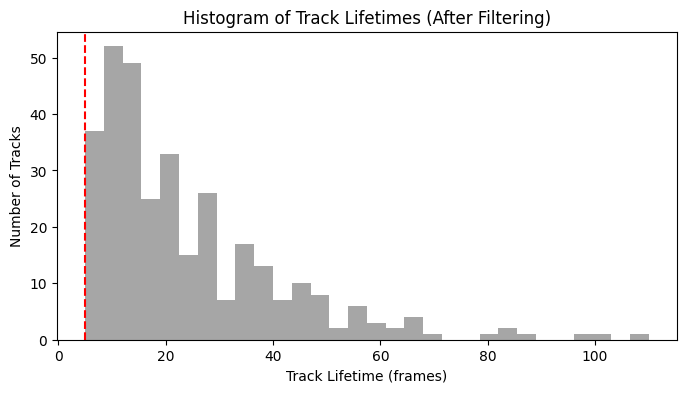

Percentage of tracks under 5 frames: 0.00%


In [83]:
#show histogram of lifetimes after filtering

plt.figure(figsize=(8, 4))
plt.hist(filtered_tracks_df['track_length'], bins=30, color='gray', alpha=0.7)
plt.axvline(x=threshold_length, color='red', linestyle='--')
plt.title('Histogram of Track Lifetimes (After Filtering)')
plt.xlabel('Track Lifetime (frames)')
plt.ylabel('Number of Tracks')
plt.show()

#print percentage of tracks under the cutoff
percentage_under_cutoff = (filtered_tracks_df[filtered_tracks_df['track_length'] < threshold_length].shape[0] / tracks_df.shape[0]) * 100
print(f"Percentage of tracks under {threshold_length} frames: {percentage_under_cutoff:.2f}%")

In [84]:
def analyze_ap2_peak_distribution(tracks, channel='c3_voxel_sum_adjusted', n_sigma=1.5):
    '''
    Analyzes the distribution of number of AP2 peaks across all tracks in the dataset.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    channel (str): Column name for the intensity data (default: 'c3_voxel_sum_adjusted')
    n_sigma (float): Threshold for burst detection (default: 1.5)

    Returns:
    dict: Contains:
        - 'peak_counts': np.array of peak counts for each track
        - 'track_ids': np.array of track IDs corresponding to peak counts
        - 'distribution': pd.Series with value_counts of peak numbers
        - 'stats': dict with mean, median, std of peak counts
    '''
    peak_counts = []
    track_ids = []
    
    for i in tqdm(range(len(tracks)), desc="Counting AP2 Peaks"):
        ap2_track = np.array(tracks[channel][i])
        ap2_bursts = detect_bursts(ap2_track, n_sigma=n_sigma)
        num_peaks = np.sum(ap2_bursts)
        
        peak_counts.append(num_peaks)
        track_ids.append(tracks['track_id'].iloc[i])
    
    peak_counts = np.array(peak_counts)
    track_ids = np.array(track_ids)
    
    # Calculate distribution
    distribution = pd.Series(peak_counts).value_counts().sort_index()
    
    # Calculate statistics
    stats = {
        'mean': np.mean(peak_counts),
        'median': np.median(peak_counts),
        'std': np.std(peak_counts),
        'min': np.min(peak_counts),
        'max': np.max(peak_counts)
    }
    
    return {
        'peak_counts': peak_counts,
        'track_ids': track_ids,
        'distribution': distribution,
        'stats': stats
    }

def plot_peak_distribution(peak_analysis_results, title='Distribution of AP2 Peaks per Track'):
    '''
    Plots the distribution of peak counts across tracks.

    Parameters:
    peak_analysis_results (dict): Output from analyze_ap2_peak_distribution
    title (str): Title for the plot
    '''
    distribution = peak_analysis_results['distribution']
    stats = peak_analysis_results['stats']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of distribution
    axes[0].bar(distribution.index, distribution.values, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of Peaks', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Tracks', fontsize=12, fontweight='bold')
    axes[0].set_title(title, fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add statistics text
    stats_text = f"Mean: {stats['mean']:.2f}\nMedian: {stats['median']:.1f}\nStd: {stats['std']:.2f}\nMin: {int(stats['min'])}\nMax: {int(stats['max'])}"
    axes[0].text(0.95, 0.95, stats_text, transform=axes[0].transAxes, 
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Cumulative distribution
    cumulative = distribution.cumsum()
    total_tracks = cumulative.iloc[-1]
    cumulative_pct = (cumulative / total_tracks) * 100
    
    axes[1].plot(cumulative_pct.index, cumulative_pct.values, marker='o', linewidth=2, markersize=6, color='darkblue')
    axes[1].set_xlabel('Number of Peaks', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim([0, 105])
    
    # Add horizontal lines at key percentiles
    for pct in [25, 50, 75]:
        axes[1].axhline(y=pct, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n=== Peak Distribution Summary ===")
    print(f"Total tracks analyzed: {len(peak_analysis_results['peak_counts'])}")
    print(f"\nStatistics:")
    for key, value in stats.items():
        print(f"  {key.capitalize()}: {value:.2f}")
    print(f"\nDistribution by peak count:")
    for num_peaks, count in distribution.items():
        percentage = (count / total_tracks) * 100
        print(f"  {int(num_peaks)} peak(s): {count} tracks ({percentage:.1f}%)")

Counting AP2 Peaks:   0%|          | 0/324 [00:00<?, ?it/s]

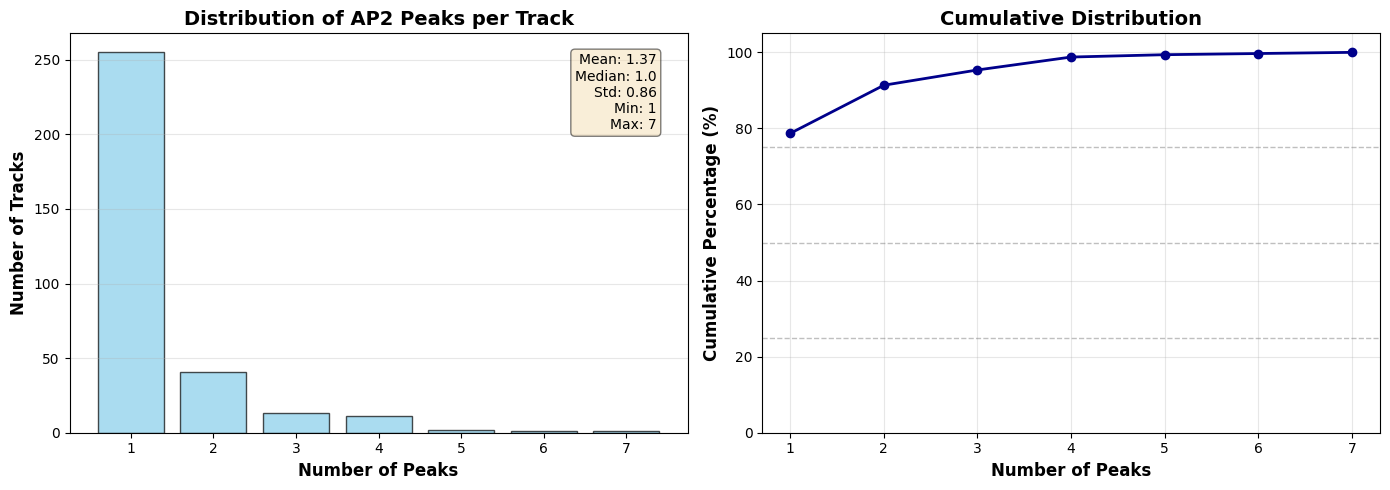


=== Peak Distribution Summary ===
Total tracks analyzed: 324

Statistics:
  Mean: 1.37
  Median: 1.00
  Std: 0.86
  Min: 1.00
  Max: 7.00

Distribution by peak count:
  1 peak(s): 255 tracks (78.7%)
  2 peak(s): 41 tracks (12.7%)
  3 peak(s): 13 tracks (4.0%)
  4 peak(s): 11 tracks (3.4%)
  5 peak(s): 2 tracks (0.6%)
  6 peak(s): 1 tracks (0.3%)
  7 peak(s): 1 tracks (0.3%)


In [85]:
# Example: Analyze AP2 peak distribution on your filtered tracks
# You can run this on any dataframe: tracks_df, filtered_tracks_df, valid_c3_tracks, etc.

peak_results = analyze_ap2_peak_distribution(
    tracks=filtered_tracks_df,  # Change this to analyze different track sets
    channel='c3_voxel_sum_adjusted',  # AP2 channel
    n_sigma=1.5  # Adjust threshold if needed
)

# Plot the distribution
plot_peak_distribution(peak_results, title='Distribution of AP2 Peaks per Track')

Counting AP2 Peaks:   0%|          | 0/5155 [00:00<?, ?it/s]

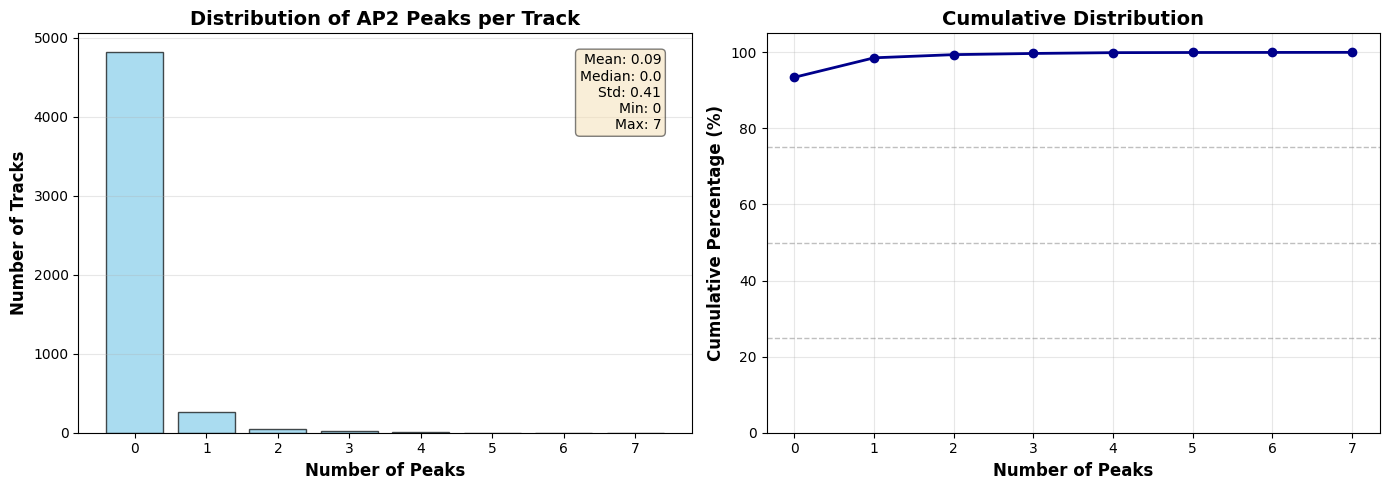


=== Peak Distribution Summary ===
Total tracks analyzed: 5155

Statistics:
  Mean: 0.09
  Median: 0.00
  Std: 0.41
  Min: 0.00
  Max: 7.00

Distribution by peak count:
  0 peak(s): 4817 tracks (93.4%)
  1 peak(s): 264 tracks (5.1%)
  2 peak(s): 43 tracks (0.8%)
  3 peak(s): 16 tracks (0.3%)
  4 peak(s): 11 tracks (0.2%)
  5 peak(s): 2 tracks (0.0%)
  6 peak(s): 1 tracks (0.0%)
  7 peak(s): 1 tracks (0.0%)


In [86]:
# Example: Analyze AP2 peak distribution on your filtered tracks
# You can run this on any dataframe: tracks_df, filtered_tracks_df, valid_c3_tracks, etc.

peak_results = analyze_ap2_peak_distribution(
    tracks=tracks_df,  # Change this to analyze different track sets
    channel='c3_voxel_sum_adjusted',  # AP2 channel
    n_sigma=1.5  # Adjust threshold if needed
)

# Plot the distribution
plot_peak_distribution(peak_results, title='Distribution of AP2 Peaks per Track')

In [88]:
testing = orderFilters(tracks_df, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, frame_order=1, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_order=3, ap2_peak=1, isGreaterPeak=True,
                    doDynminBurstFilter=False, dynmin_order=2, dist_max=10,
                    doLinearityFilter=True, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True)

Filter step 0, Applying filter_pixel_spots...
After filter_pixel_spots: 4933 tracks remain, 222 tracks dropped.
Filter step 1, Applying filter_track_frames...
After filter_track_frames: 4802 tracks remain, 131 tracks dropped.
Filter step 3, Applying filter_ap2_peaks...


Processing AP2 Peaks:   0%|          | 0/4802 [00:00<?, ?it/s]

After filter_ap2_peaks: 324 tracks remain, 4478 tracks dropped.
Filter step 4, Applying filter_linearity...


Processing tracks:   0%|          | 0/324 [00:00<?, ?it/s]

After filter_linearity: 50 tracks remain, 274 tracks dropped.
Final number of tracks after all filters:, 50 and total tracks dropped: 5105


In [89]:
testing['ap2_peaks_dropped']

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,179 127.0 423 128.0 540 127.0 620 ...,179 62.0 423 62.0 540 62.0 620 ...,179 39.0 423 40.0 540 39.0 620 ...,135,13,1,13,143.737143,264.920000,446.337143,...,"[199.6578947368398, 1328.0789473684126, 26.605...",1354.657895,1074.368421,1328.078947,13,13,2,2.0,1.0,2.0
1,178 154.0 424 155.0 528 154.0 633 ...,178 33.0 424 34.0 528 33.0 633 ...,178 54.0 424 58.0 528 57.0 633 ...,136,13,1,13,147.560000,307.285714,520.142857,...,"[695.1315789473592, 1594.0789473684126, 13.526...",1656.236842,2136.473684,1958.763158,9,7,12,5.0,1.0,2.0
2,175 206.0 406 207.0 563 206.0 635 ...,175 163.0 406 163.0 563 163.0 635 ...,175 90.0 406 88.0 563 87.0 635 ...,137,14,1,15,179.102857,281.565714,465.154286,...,"[1490.1578947368398, -873.0, 1593.394736842106...",2911.421053,1946.368421,1593.394737,1,3,3,4.0,2.0,4.0
3,173 171.0 404 170.0 553 171.0 621 ...,173 100.0 404 100.0 553 101.0 621 ...,173 66.0 404 66.0 553 66.0 621 ...,138,7,1,7,152.971429,261.662857,546.285714,...,"[-755.0263157894806, 905.5, 1440.0526315789466...",1412.157895,1232.447368,1440.052632,3,1,3,2.0,5.0,2.0
4,171 105.0 398 103.0 562 104.0 619 ...,171 218.0 398 218.0 562 218.0 619 ...,171 38.0 398 39.0 562 35.0 619 ...,139,6,1,6,104.948571,122.434286,114.668571,...,"[-35.23684210526335, -302.4210526315801, 190.6...",324.815789,443.289474,190.605263,3,6,3,8.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4473,"32161 251.0 32219 251.0 Name: mu_x, dtyp...","32161 135.0 32219 136.0 Name: mu_y, dtyp...","32161 128.0 32219 129.0 Name: mu_z, dtyp...",5150,2,203,204,125.874286,192.531429,433.600000,...,"[2016.1842105263058, 277.263157894733]",664.842105,934.447368,2016.184211,203,203,203,1.0,1.0,0.0
4474,"32158 289.0 32220 287.0 Name: mu_x, dtyp...","32158 114.0 32220 114.0 Name: mu_y, dtyp...","32158 143.0 32220 144.0 Name: mu_z, dtyp...",5151,2,203,204,102.125714,114.611429,109.045714,...,"[73.78947368420995, -1.8684210526334937]",296.342105,214.184211,73.789474,204,204,203,1.0,0.0,2.0
4475,"32152 290.0 32210 289.0 Name: mu_x, dtyp...","32152 114.0 32210 114.0 Name: mu_y, dtyp...","32152 148.0 32210 148.0 Name: mu_z, dtyp...",5152,2,203,204,101.262857,115.525714,108.194286,...,"[-6.131578947370144, 14.26315789473665]",134.157895,280.157895,14.263158,203,203,204,0.0,0.0,1.0
4476,"32150 288.0 32215 290.0 Name: mu_x, dtyp...","32150 211.0 32215 211.0 Name: mu_y, dtyp...","32150 148.0 32215 150.0 Name: mu_z, dtyp...",5153,2,203,204,102.114286,111.662857,104.337143,...,"[207.0263157894733, 240.6052631578932]",223.289474,157.447368,240.605263,204,203,204,2.0,0.0,2.0


#### Intensities of dropped tracks

In [90]:
def test_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, track_id_col_name: str, 
                       frame_col_name: str, intensity_to_plot: list, channels_to_plot: int, legend_values: list = ['Channel 3', 'Channel 2', 'Channel 1'], 
                       line_colors: list = ['red', 'green', 'blue'], graph_title = 'Intensity', normalized: bool = False):
    
    '''
    
    The function takes in the list of track ids assigned to a cohort and aligns them with respect to their 
    peak values to a specific index. The index depends on bufferZero. Whatever the value of bufferZero is the
    peaks will be aligned with that value. 
    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    1. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    4. intensity_to_plot, type(list), the name of the columns to be used for plotting intensity. Note that the first value
    in this list should be for the primary channel, second value for the secondary channel and so on. 
    Default Value: ['amplitude', 'c2_peak']
    5. track_id_col_name: type(str), the column name which contains the frame number. Default value: 'track_id'
    6. legend_values: type(list), labels for the legend. Must be in line with intensity_to_plot list. The channel that is first in intensity_to_plot
    must also appear first in legend labels. 
    7. line_colors: type(list), colors for the intensity_to_plot lines. line_colors[0] will be the color for intensity_to_plot[0] and so on. 
    8. normalized: type(bool), if the intensity values are normalized. Default value: False

    Output: 
    1. Returns the array of primary channel tracks aligned with respect to secondary channel peaks
    2. Returns the array of secondary channel tracks where tracks are aligned with all peaks of tracks being on 
    the same index. (the index is determined by bufferZero)
    
    '''


    if channels_to_plot == 3 and len(intensity_to_plot) != 3: 
        raise ValueError('length of intensity_to_plot must equal channels_to_plot')
        
    num_rows = 1
    num_cols = 5
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(17.5, 6))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else np.array([axes])
    handles = []
    labels = []

    for i, track_id in enumerate(tracks_to_plot):
        # Filter DataFrame for the selected track_id
        track_data = dataframe[dataframe[track_id_col_name] == track_id].copy(deep = True)

        #length = filtered_df[filtered_df['track_id'] == track_id]['track_length'].values
        length = track_data.shape[0]

        lines = []
        for j in range(channels_to_plot):
            min_val = track_data[intensity_to_plot[j]].min()
            track_data[intensity_to_plot[j]] -= min_val
            max_val = track_data[intensity_to_plot[j]].max()          

            # normalize by max_intensity
            if normalized:  
                track_data[intensity_to_plot[j]] /= max_val
            line, = axes[i].plot(track_data[frame_col_name], track_data[intensity_to_plot[j]], label=intensity_to_plot[j], color=line_colors[j])
            lines.append(line)

        # if channels_to_plot == 2:
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1], color = line_colors[1])
        # else: 
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     min2 = track_data[intensity_to_plot[2]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     track_data[intensity_to_plot[2]] = track_data[intensity_to_plot[2]] - min2
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1],  color = line_colors[1])
        #     line3, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[2]], label=intensity_to_plot[2], color = line_colors[2])
        axes[i].set_title(f'Track {track_id}, length {length}')
        axes[i].set_xlabel('Frame')
        axes[i].set_ylabel('Intensity')
        #axes[row, col].legend()

    fig.suptitle(f'{graph_title} over time', fontsize = 16, fontweight = 'bold')

    for i in range(channels_to_plot):
        handles.append(lines[i])
        labels.append(legend_values[i])
    # if (channels_to_plot == 2):
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2])
    #     labels.extend([legend_values[0], legend_values[1]])
    # else: 
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2, line3])
    #     labels.extend([legend_values[0], legend_values[1], legend_values[2]])
        
    # Set a single legend for all subplots
    fig.legend(handles, labels, loc='upper right', ncol=channels_to_plot, fontsize=18)
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.8, hspace=0.7)
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

In [93]:
filtered_tracks_df

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,number_of_frames,color
0,285 197.0 452 197.0 685 196.0 861 ...,285 195.0 452 195.0 685 195.0 861 ...,285 85.0 452 85.0 685 87.0 861 ...,160,8,1,9,154.777143,284.308571,479.925714,...,642.868421,1462.657895,3,6,2,5.0,1.0,3.0,8,222
1,306 106.0 569 107.0 687 106.0 856 ...,306 143.0 569 146.0 687 144.0 856 ...,306 52.0 569 52.0 687 54.0 856 ...,166,27,2,28,160.754286,341.662857,668.480000,...,4134.324324,9446.500000,26,11,3,4.0,3.0,3.0,27,168
2,334 237.0 572 237.0 643 237.0 781 ...,334 79.0 572 79.0 643 78.0 781 ...,334 128.0 572 127.0 643 127.0 781 ...,167,13,2,14,177.057143,306.205714,545.862857,...,2077.394737,796.605263,9,5,3,3.0,2.0,1.0,13,255
3,585 115.0 623 115.0 806 113.0 979 ...,585 95.0 623 95.0 806 96.0 979 ...,585 31.0 623 31.0 806 31.0 979 ...,189,16,3,18,145.817143,261.120000,546.885714,...,775.868421,7868.157895,9,16,12,2.0,3.0,3.0,16,92
4,728 157.0 803 156.0 1017 157.0 1134...,728 25.0 803 26.0 1017 26.0 1134 ...,728 81.0 803 84.0 1017 82.0 1134 ...,216,53,4,58,144.577143,269.085714,525.068571,...,2034.736842,3414.088235,20,37,42,4.0,8.0,9.0,53,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,30560 102.0 30711 101.0 30889 103.0 3...,30560 154.0 30711 153.0 30889 155.0 3...,30560 53.0 30711 52.0 30889 53.0 3107...,4885,9,193,201,133.811429,206.588571,512.411429,...,707.342105,883.184211,197,199,198,2.0,2.0,3.0,9,220
320,30696 194.0 30893 193.0 30991 193.0 3...,30696 106.0 30893 106.0 30991 106.0 3...,30696 80.0 30893 79.0 30991 80.0 3112...,4895,11,194,204,157.285714,216.994286,512.160000,...,817.526316,1179.052632,201,195,202,2.0,1.0,3.0,11,148
321,30848 213.0 30970 212.0 31125 212.0 3...,30848 200.0 30970 200.0 31125 200.0 3...,30848 111.0 30970 113.0 31125 113.0 3...,4917,10,195,204,143.588571,213.068571,416.354286,...,2853.447368,3263.026316,199,197,199,4.0,1.0,3.0,10,54
322,31080 238.0 31242 239.0 31286 239.0 3...,31080 114.0 31242 115.0 31286 115.0 3...,31080 132.0 31242 132.0 31286 132.0 3...,4943,9,196,204,140.788571,210.428571,463.840000,...,1432.638889,2191.108108,200,200,197,1.0,1.0,1.0,9,62


KeyError: 'frame'

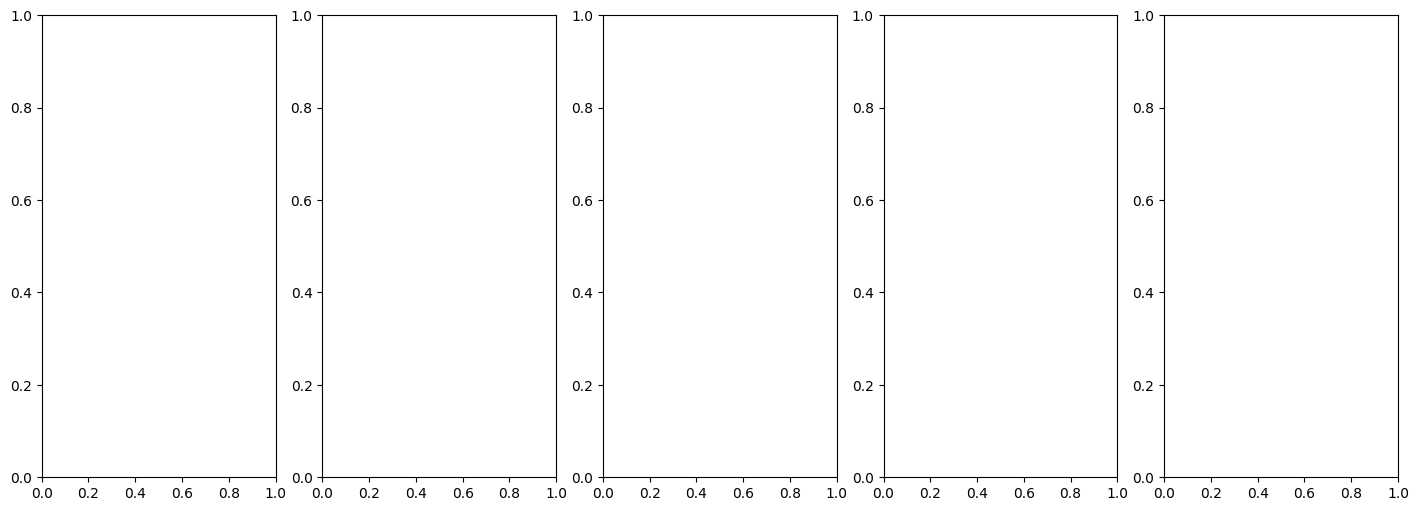

In [ ]:
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = testing["ap2_peaks_dropped"], desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 5)

test_intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

In [94]:
z_max = z2.shape[2]
y_max = z2.shape[3]
x_max = z2.shape[4]
print("x_max:", x_max, "y_max:", y_max, "z_max:", z_max)

x_max: 343 y_max: 239 z_max: 157


Filter out tracks based on length and completeness

### Determining Valid Channel 3 tracks 
valid_c3_tracks will serve as baseline "clathrin positive" and valid tracks

In [111]:
### Dropping tracks with Channel 3 peak in the last frame
# valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_peak_frame')
valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_voxel_sum_adjusted_peak_frame')

### Dropping tracks with Channel 3 which have their peaks in the first three frames 
# valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_peak_frame',
#                                       cutoff = peak_cutoff)
valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_voxel_sum_adjusted_peak_frame',
                                      cutoff = peak_cutoff)

valid_c3_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,number_of_frames,color
1,306 106.0 569 107.0 687 106.0 856 ...,306 143.0 569 146.0 687 144.0 856 ...,306 52.0 569 52.0 687 54.0 856 ...,166,27,2,28,160.754286,341.662857,668.480000,...,4134.324324,9446.500000,26,11,3,4.0,3.0,3.0,27,168
2,334 237.0 572 237.0 643 237.0 781 ...,334 79.0 572 79.0 643 78.0 781 ...,334 128.0 572 127.0 643 127.0 781 ...,167,13,2,14,177.057143,306.205714,545.862857,...,2077.394737,796.605263,9,5,3,3.0,2.0,1.0,13,255
3,585 115.0 623 115.0 806 113.0 979 ...,585 95.0 623 95.0 806 96.0 979 ...,585 31.0 623 31.0 806 31.0 979 ...,189,16,3,18,145.817143,261.120000,546.885714,...,775.868421,7868.157895,9,16,12,2.0,3.0,3.0,16,92
4,728 157.0 803 156.0 1017 157.0 1134...,728 25.0 803 26.0 1017 26.0 1134 ...,728 81.0 803 84.0 1017 82.0 1134 ...,216,53,4,58,144.577143,269.085714,525.068571,...,2034.736842,3414.088235,20,37,42,4.0,8.0,9.0,53,197
6,703 214.0 872 216.0 944 219.0 1161...,703 201.0 872 200.0 944 201.0 1161...,703 95.0 872 95.0 944 96.0 1161 ...,219,20,4,23,185.274286,295.200000,517.542857,...,2583.473684,1240.868421,12,16,6,7.0,11.0,19.0,20,157


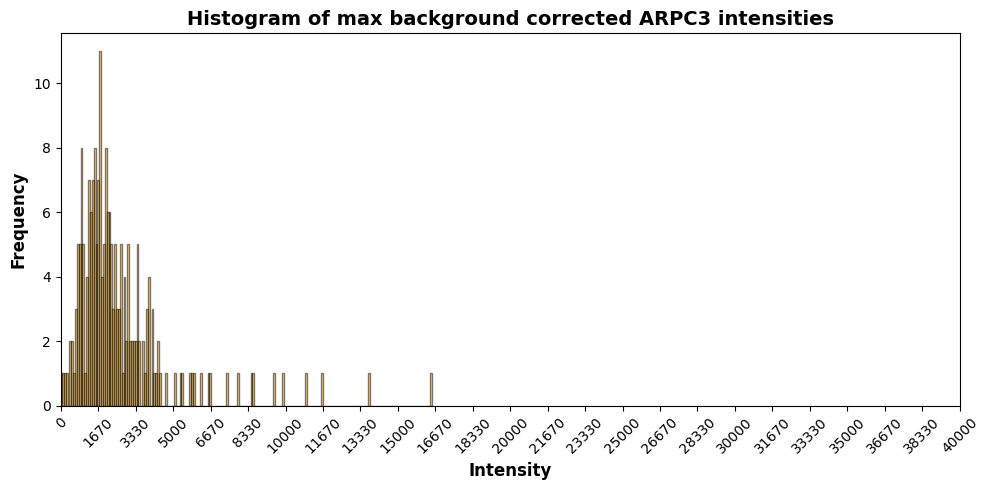

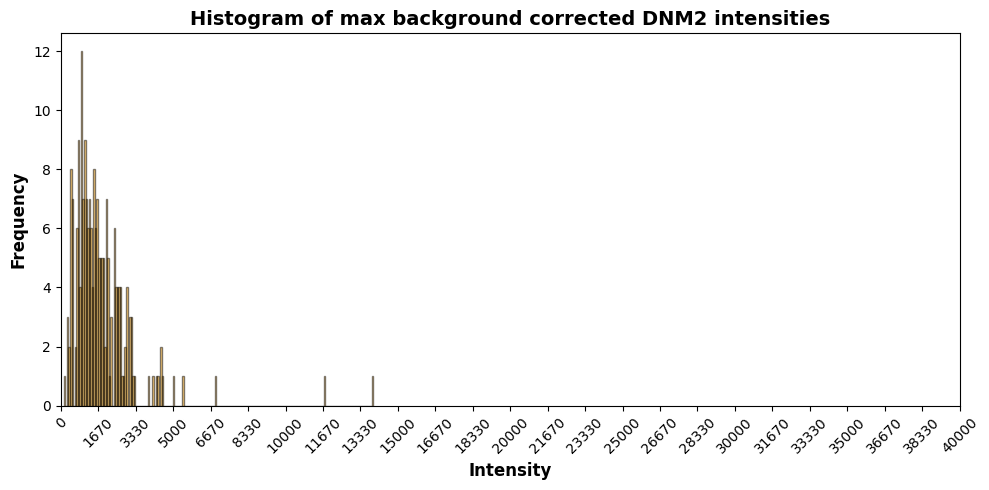

In [96]:
# Histogram of maximum background corrected ARPC3 intensity values, to determine cutoff for ARPC3-positive tracks
columns = ['c1_voxel_sum_adjusted_peak', 'c2_voxel_sum_adjusted_peak']
marker = ['ARPC3', 'DNM2']

# # Max AP2 intensity per track
# control_AP2 = tracks_channel_subset_control['C3_adjusted_voxel_sum'].reset_index(drop=True)

# max_control_AP2 = []
# for j in range(len(control_AP2)):
#     max_control_AP2.append(max(control_AP2[j]))  

for i in range(len(columns)):
    # Create a figure with 2 subplots side by side
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    control =  valid_c3_tracks[columns[i]].reset_index(drop=True)
    

    max_control = []
    for j in range(len(control)):
        max_control.append(control[j])  # For every element in arpc3_control, get the max value



    # # Normalize to max AP2 intensity, optional
    # max_control = (np.array(max_control) / np.array(max_control_AP2)).tolist()
    


    # Generate 50 equally spaced bins between the min and max of max_arpc3_control and max_arpc3_OS
    # so I can plot the histograms of max_arpc3_control and max_arpc3_OS on the same plot
    # with the same binning
    bins = np.linspace(min(max_control), max(max_control), 200)


    # Plot histogram on the first subplot
    ax1.hist(max_control, bins=bins, color='orange', edgecolor='black', alpha=0.5, label='Control')

    # Calculate the data range
    # x_min = min(max_control)
    # x_max = max(max_control)
    x_min = 0
    x_max = 40000
    
    # Round minimum down and maximum up to nearest 10
    x_min_rounded = np.floor(x_min / 10) * 10
    x_max_rounded = np.ceil(x_max / 10) * 10
    
    # Create tick marks rounded to the nearest 10
    num_ticks =25  # Adjust this number for more or fewer ticks
    
    # Generate ticks rounded to the nearest 10
    x_ticks = np.linspace(x_min_rounded, x_max_rounded, num_ticks)
    x_ticks_rounded = np.round(x_ticks / 10) * 10  # Round to nearest 10
    
    ax1.set_xticks(x_ticks_rounded)
    ax1.set_xticklabels([f'{int(x)}' for x in x_ticks_rounded], rotation=45, fontsize=10)
    
    ax1.set_xlabel('Intensity', fontsize=12, weight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax1.set_title('Histogram of max background corrected' + ' ' + marker[i] + ' ' +  'intensities', fontsize=14, weight='bold')

    # set x limit to 0 and 20000
    ax1.set_xlim(x_min_rounded, x_max_rounded)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [35]:
# valid_c3_tracks_filter = valid_c3_tracks[valid_c3_tracks['C1_adjusted_voxel_sum_peak'] > 4000]

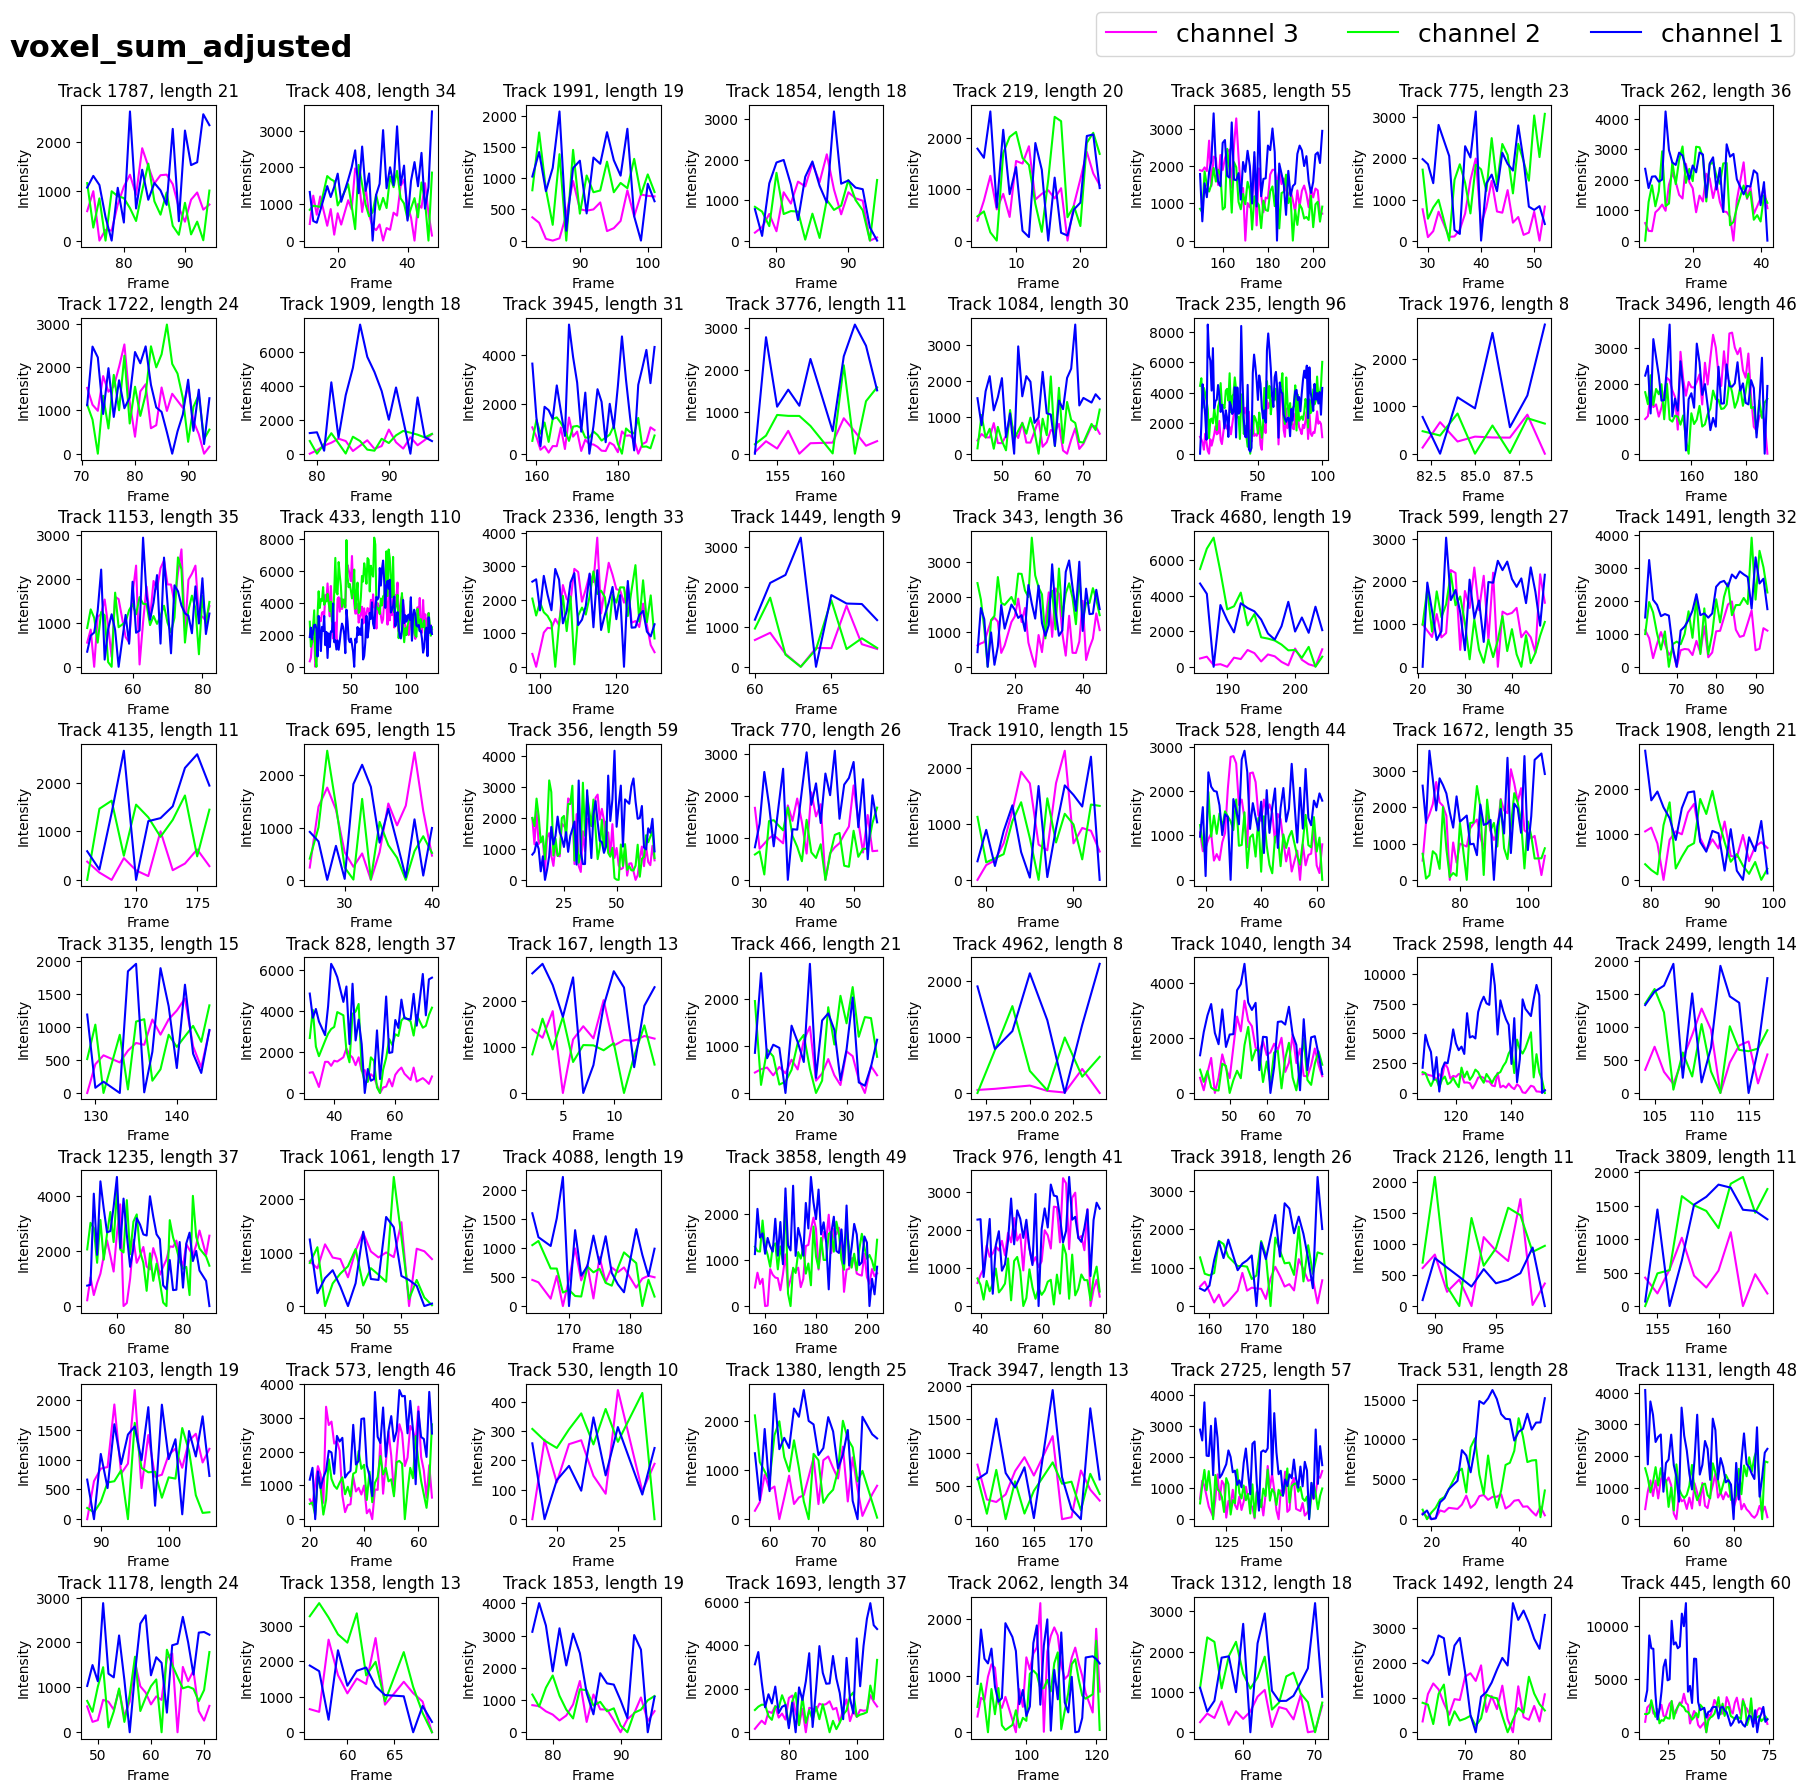

In [97]:
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = valid_c3_tracks, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 64)

intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

### Filtering for Channel 2 
dnm2_positive_tracks will serve as the baseline for dynamin positive tracks

In [98]:
# Channel 2-positive tracks

# dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
#                                           intensity_peak_frame = 'c2_peak')

dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
                                          intensity_peak_frame = 'c2_voxel_sum_adjusted_peak')

### Filter tracks based on channel 2 peak if occurs within 3 frames of starting of a track 

# dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_peak_frame', 
#                                       cutoff = peak_cutoff)

dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

### Filter tracks based on channel 2 peaks occuring in the last frame 

# dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_peak_frame')

dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_voxel_sum_adjusted_peak_frame')
dnm2_positive_tracks.shape

(107, 32)

### Identifying Channel 1 positive tracks 

In [113]:
### Identifying Actin Positive Tracks 
# actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
#                                           intensity_peak_frame = 'c1_peak' )

actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
                                          intensity_peak_frame = 'c1_voxel_sum_adjusted_peak' )

### Filter tracks based on channel 1 peaks if occurs within the first 3 frames 

# actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_peak_frame', 
#                                       cutoff = peak_cutoff)

actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

# actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_peak_frame')

actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_voxel_sum_adjusted_peak_frame')

Combining actin and dynamin positive tracks with valid clathrin positive tracks 

In [114]:
final_tracks = valid_c3_tracks.copy(deep = True)
final_tracks['channel2_positive'] = False 
final_tracks['channel1_positive'] = False 

In [115]:
# ***Setting actin positive tracks to True***

# Get the track IDs from actin_positive_tracks
actin_positive_track_ids = actin_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(actin_positive_track_ids), 'channel1_positive'] = True

actin_rows_count = final_tracks[final_tracks['channel1_positive'] == True].shape[0]
print(f'number of {channel1_name} positive tracks are: {actin_rows_count}')

# ***Setting dynamin positive tracks to True***

# Get the track IDs from actin_positive_tracks
dnm2_positive_track_ids = dnm2_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(dnm2_positive_track_ids), 'channel2_positive'] = True

dnm2_rows_count = final_tracks[final_tracks['channel2_positive'] == True].shape[0]
print(f'number of {channel2_name} positive tracks are: {dnm2_rows_count}')


actin_dnm2_rows_count = final_tracks[(final_tracks['channel2_positive'] == True) & 
                                     (final_tracks['channel1_positive'] == True)].shape[0]
print(f"number of {channel1_name} and {channel2_name} positive tracks are: {actin_dnm2_rows_count}")

number of channel 1 positive tracks are: 123
number of channel 2 positive tracks are: 107
number of channel 1 and channel 2 positive tracks are: 73


### Estimating Apical/Basal/Lateral boundaries of cell
Based on the slices with the most intensity in channel 1

In [116]:
import importlib
import filters
importlib.reload(filters)

<module 'filters' from '/Users/valerie/LLSM-CME-ANALYSIS/Final/src/filters.py'>

In [117]:
#channel is hard coded in the function right now. Need to allow it to be passed as a parameter by the user 
if membrane_regions_exist == True:      
    boundaries = plot_z_sum_bd(z2)
else: print("Membrane regions do not exist, skipping boundary plot.")
# print(boundaries)

Membrane regions do not exist, skipping boundary plot.


This Z axis plot shows where the max intensities are, which roughly correspond to the basal and apical regions of the cell.

The lines are the auto-detected boundaries between basal, lateral, and apical.  

If needed, you can scan through the z series in Napari below to adjust the position of these boundaries.

In [118]:
# If ychange the values of the boundaries to the ones you want to use

basal_lateral_boundary_slice_manual = []
lateral_apical_boundary_slice_manual = []

if membrane_regions_exist == True and basal_lateral_boundary_slice_manual:
    boundaries = [basal_lateral_boundary_slice_manual, lateral_apical_boundary_slice_manual]
    print('Manual basal-lateral boundary slice is:', basal_lateral_boundary_slice_manual)   
    print('Manual lateral-apical boundary slice is:', lateral_apical_boundary_slice_manual)

elif membrane_regions_exist == True:
    print('Basal-lateral boundary slice is:', boundaries[0])   
    print('Lateral-apical boundary slice is:', boundaries[1]) 

else:
    print('Analyzing whole cell without membrane regions')   



Analyzing whole cell without membrane regions


In [119]:
# Allocate membrane regions based on the boundaries defined above
if membrane_regions_exist == True: 
    allocate_membrane_regions(df = final_tracks, basal_range = [0,25] , lateral_range = [25,75], apical_range = [75,112])

else: 
    final_tracks['membrane_region'] = 'Basal'

In [120]:
# # Subset final tracks such that 25 is less than mean_z less than 30
# final_tracks[(final_tracks['mean_z'] > 25) & (final_tracks['mean_z'] < 30)][['mean_z', 'membrane_region']]
final_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,number_of_frames,color,channel2_positive,channel1_positive,membrane_region
1,306 106.0 569 107.0 687 106.0 856 ...,306 143.0 569 146.0 687 144.0 856 ...,306 52.0 569 52.0 687 54.0 856 ...,166,27,2,28,160.754286,341.662857,668.480000,...,11,3,4.0,3.0,3.0,27,168,True,False,Basal
2,334 237.0 572 237.0 643 237.0 781 ...,334 79.0 572 79.0 643 78.0 781 ...,334 128.0 572 127.0 643 127.0 781 ...,167,13,2,14,177.057143,306.205714,545.862857,...,5,3,3.0,2.0,1.0,13,255,False,False,Basal
3,585 115.0 623 115.0 806 113.0 979 ...,585 95.0 623 95.0 806 96.0 979 ...,585 31.0 623 31.0 806 31.0 979 ...,189,16,3,18,145.817143,261.120000,546.885714,...,16,12,2.0,3.0,3.0,16,92,False,True,Basal
4,728 157.0 803 156.0 1017 157.0 1134...,728 25.0 803 26.0 1017 26.0 1134 ...,728 81.0 803 84.0 1017 82.0 1134 ...,216,53,4,58,144.577143,269.085714,525.068571,...,37,42,4.0,8.0,9.0,53,197,True,True,Basal
6,703 214.0 872 216.0 944 219.0 1161...,703 201.0 872 200.0 944 201.0 1161...,703 95.0 872 95.0 944 96.0 1161 ...,219,20,4,23,185.274286,295.200000,517.542857,...,16,6,7.0,11.0,19.0,20,157,True,False,Basal


Save tracks

In [121]:
final_tracks.to_pickle(output_directory_full)

# Visualize tracks in Napari to assess track filtering quality

In [122]:
# Report number of frames and a random color per track

import random

# Calculate the number of unique frames for each track and create a mapping from track_id to number_of_frames
frame_counts = track_df.groupby('track_id')['frame'].nunique().to_dict()

# Map the frame counts to the original dataframe, creating a new column
track_df['number_of_frames'] = track_df['track_id'].map(frame_counts)

# Assuming 'track_df' is your DataFrame
track_ids = track_df['track_id'].unique().tolist()

# Generate a list of random colors
colors = [random.randint(0, 255) for _ in range(len(track_ids))]

# Create a dictionary that maps each track id to a random color
color_dict = dict(zip(track_ids, colors))

# Now you can use this dictionary to assign colors to the tracks
track_df['color'] = track_df['track_id'].map(color_dict)

# Sort track_df by frame and track_id
track_df = track_df.sort_values(by=['frame', 'track_id']).reset_index(drop=True)

track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,sigma_z,sigma_y,sigma_x,c1_peak_mean,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,206.0,184.0,110.0,343.0,0,3,2,2,456.731429,...,412,41288,8274.842105,204,183,110,175,441,205,106
1,0,151.0,101.0,70.0,96.0,1,3,2,2,437.274286,...,182,26262,339.631579,153,100,73,175,441,60,173
2,0,185.0,135.0,80.0,142.0,2,3,2,2,640.708571,...,242,33760,3541.578947,183,135,83,175,441,57,170
3,0,221.0,83.0,94.0,196.0,3,3,2,2,565.160000,...,268,36667,3255.815789,220,83,97,175,441,51,192
4,0,165.0,150.0,84.0,160.0,4,3,2,2,517.034286,...,222,31632,1307.000000,165,152,81,175,441,43,183


In [127]:
# Create a napari viewer
viewer = napari.Viewer()

#access channel 3 only from zarr array 
dask_array = da.from_zarr(z2)

#the axis arrangement is (t,c,z,y,x)
#for the sake of improved performance only 1 channel could be imported here (if images get super large and performance issues occur)
all_channels = dask_array[:,:,:,:,:]

# # Calculate the 1st and 99th percentiles for the 10th time point
# lower_limit_1, upper_limit_1 = da.percentile(all_channels[10,0,:,:,:].ravel(), [5, 95]).compute()
# lower_limit_2, upper_limit_2 = da.percentile(all_channels[10,1,:,:,:].ravel(), [5, 95]).compute()
# lower_limit_3, upper_limit_3 = da.percentile(all_channels[10,2,:,:,:].ravel(), [5, 95]).compute()


# # Set the contrast limits

# # Add each channel as a separate image layer with its own contrast limits
# layer_raw_1 = viewer.add_image(all_channels[0], contrast_limits=[lower_limit_1, upper_limit_1], name='channel 1', colormap='yellow')
# layer_raw_2 = viewer.add_image(all_channels[1], contrast_limits=[lower_limit_2, upper_limit_2], name='channel 2', colormap = 'cyan')
# layer_raw_3 = viewer.add_image(all_channels[2], contrast_limits=[lower_limit_3, upper_limit_3], name='channel 3', colormap = 'magenta')

# Add the 4D stack to the viewer
layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'])
#other useful parameters 
#color_map = list
#contrast_limits = list of list 

track_properties = {'number_of_frames': track_df['number_of_frames'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}
# track_properties = {'number_of_frames': track_df['track_length'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}


# viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks')

tracks_layer = viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

# Add Bounding Box
layer_raw[0].bounding_box.visible = True
layer_raw[1].bounding_box.visible = True
layer_raw[2].bounding_box.visible = True


/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/napari/layers/tracks/tracks.py:652: UserWarning: Previous color_by key 'track_id_rand' not present in features. Falling back to track_id
  warn(


In [ ]:
# # Displaying only filtered tracks
# filtered_track_ids = final_tracks['track_id'].unique().tolist()
# filtered_track_df = track_df[track_df['track_id'].isin(filtered_track_ids)].copy(deep = True)
# filtered_tracks_layer = viewer.add_tracks(filtered_track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'filtered tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/napari/layers/tracks/tracks.py:652: UserWarning: Previous color_by key 'track_id_rand' not present in features. Falling back to track_id
  warn(


ValueError: Length of values (32342) does not match length of index (6312)

In [132]:
#Displaying Dynamin Positive tracks only (Tracks where actin is not present)
dnm2_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == False)]
dnm2_tracks_list = dnm2_positive_tracks_df['track_id'].values
track_1 = track_df[track_df['track_id'].isin(dnm2_tracks_list)]
viewer.add_tracks(track_1[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel2+ tracks')
print(len(dnm2_tracks_list), 'channel2 positive tracks displayed')


34 channel2 positive tracks displayed


In [133]:
#Displaying Actin Positive tracks only (Tracks where Dynamin is not present)
actin_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == False) & (final_tracks['channel1_positive'] == True)]
actin_tracks_list = actin_positive_tracks_df['track_id'].values
track_2 = track_df[track_df['track_id'].isin(actin_tracks_list)]
viewer.add_tracks(track_2[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel1+ tracks')
print(len(actin_tracks_list), 'channel1 positive tracks displayed')

50 channel1 positive tracks displayed


In [131]:
#Displaying all 3 channels positive tracks 
all_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == True)]
all_positive_tracks_list = all_positive_tracks_df['track_id'].values
track_3 = track_df[track_df['track_id'].isin(all_positive_tracks_list)]
viewer.add_tracks(track_3[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all+ tracks')

<Tracks layer 'all+ tracks' at 0x7f9a1058eb00>

In [126]:
#Displaying basal tracks 
if membrane_regions_exist == True: 
    basal_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Basal']
    basal_tracks_list = basal_tracks_df['track_id'].values
    track_4 = track_df[track_df['track_id'].isin(basal_tracks_list)]
    viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'basal tracks')

In [30]:
# #Displaying lateral tracks 
# if membrane_regions_exist == True:
#     lateral_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Lateral']
#     lateral_tracks_list = lateral_tracks_df['track_id'].values
#     track_5 = track_df[track_df['track_id'].isin(lateral_tracks_list)]
#     viewer.add_tracks(track_5[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Lateral tracks')

In [31]:
# #Displaying apical tracks 
# if membrane_regions_exist == True:
#     apical_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Apical']
#     apical_tracks_list = apical_tracks_df['track_id'].values
#     track_6 = track_df[track_df['track_id'].isin(apical_tracks_list)]
#     viewer.add_tracks(track_6[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Apical tracks')

### final_tracks dataframe stores tracks which are at least positive in the channel you tracked.

## Once you have performed this step and have filtered tracks  you can now use the dashboard to test performance of the pipeline and access visualisations. 

# Go to multipage_dashboard and run app.py 